# 1. IMPORTAÇÃO DE BIBLIOTECAS

DESCRIÇÃO DOS DATASETS - FONTE: CVM (Comissão de Valores Mobiliários)

Dataset 1 - DRE (Demonstração de Resultados):
  • Origem: CVM - Dados Abertos (formato ZIP consolidado)
  • Formato: Estruturado (CSV dentro de ZIP)
  • Estrutura: Contas contábeis por empresa/período
  • Volume Estimado: ~500 empresas × 15 anos × 4 trimestres ≈ 30,000 registros
  • Frequência: Anual (DFP)
  • Veracidade: Alta - dados oficiais auditados
  • Colunas Principais: ['Receita Líquida', 'Lucro Líquido', 'EBITDA', 'Custos']

Dataset 2 - Balanço Patrimonial (BPA/BPP):
  • Origem: CVM - Dados Abertos (formato ZIP consolidado)
  • Formato: Estruturado (CSV dentro de ZIP)
  • Estrutura: Ativos, Passivos e Patrimônio Líquido
  • Volume Estimado: ~500 empresas × 15 anos ≈ 7,500 registros
  • Frequência: Anual (DFP)
  • Veracidade: Alta - dados oficiais auditados
  • Colunas Principais: ['Ativo Total', 'Passivo Total', 'Patrimônio Líquido']

CONFIGURAÇÃO DA ANÁLISE
• Período: 2010 a 2025
• Anos para análise: 16 an

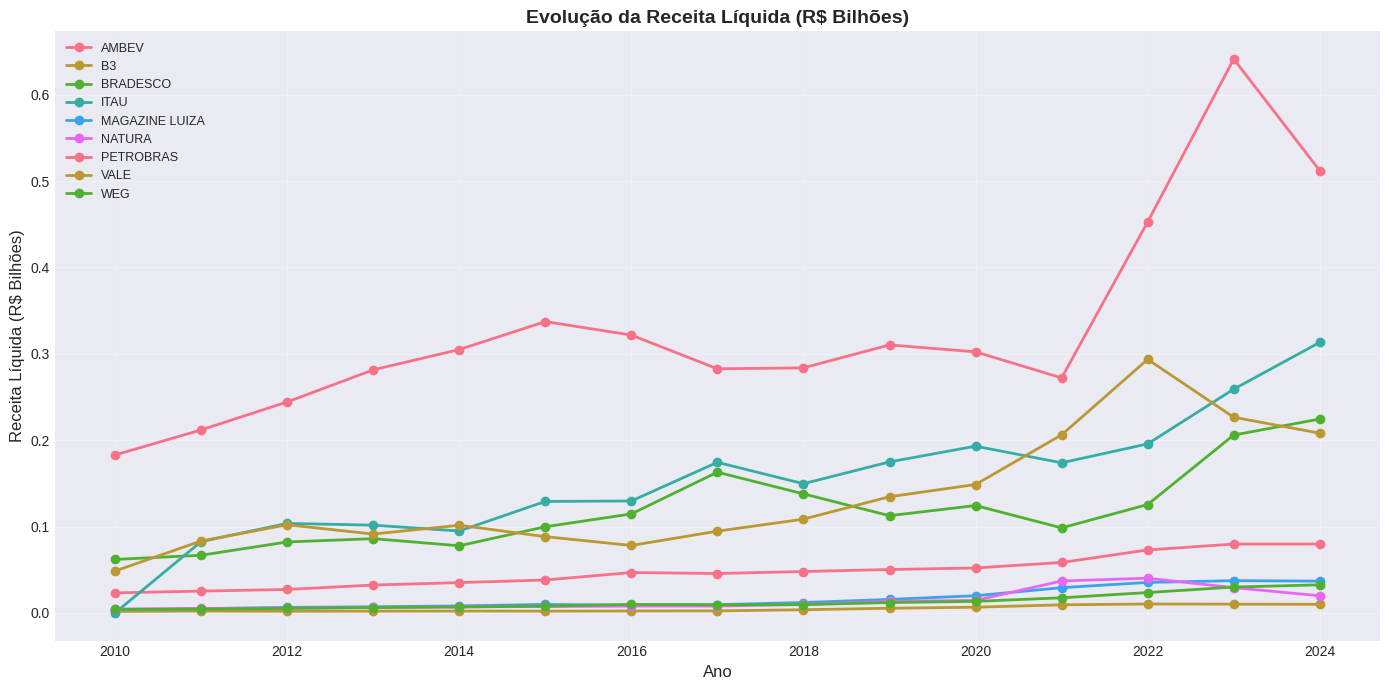

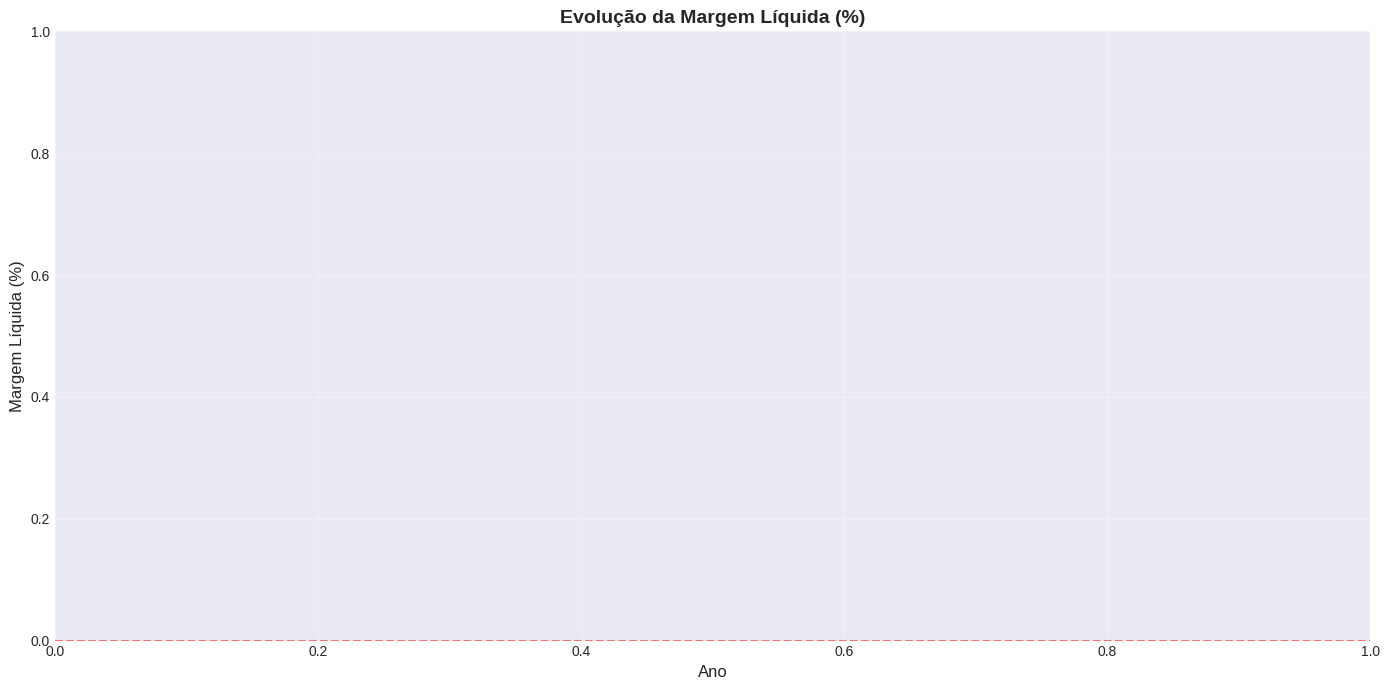

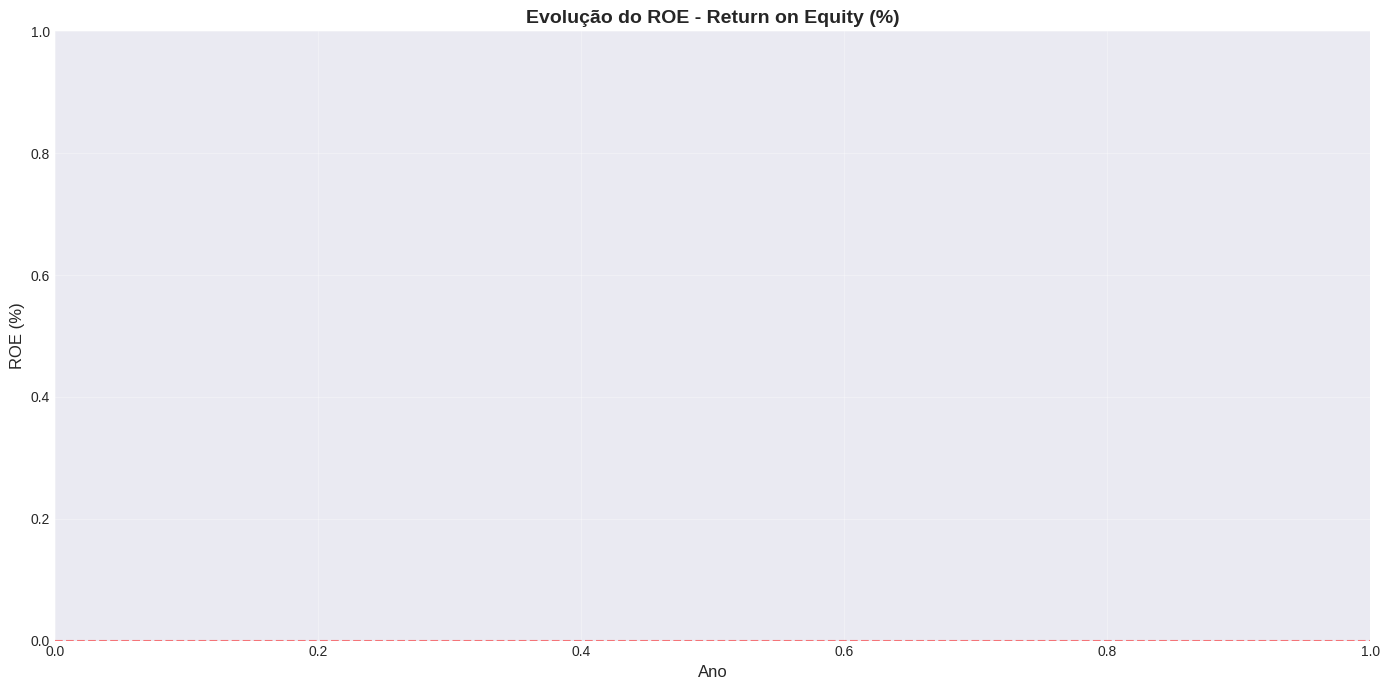

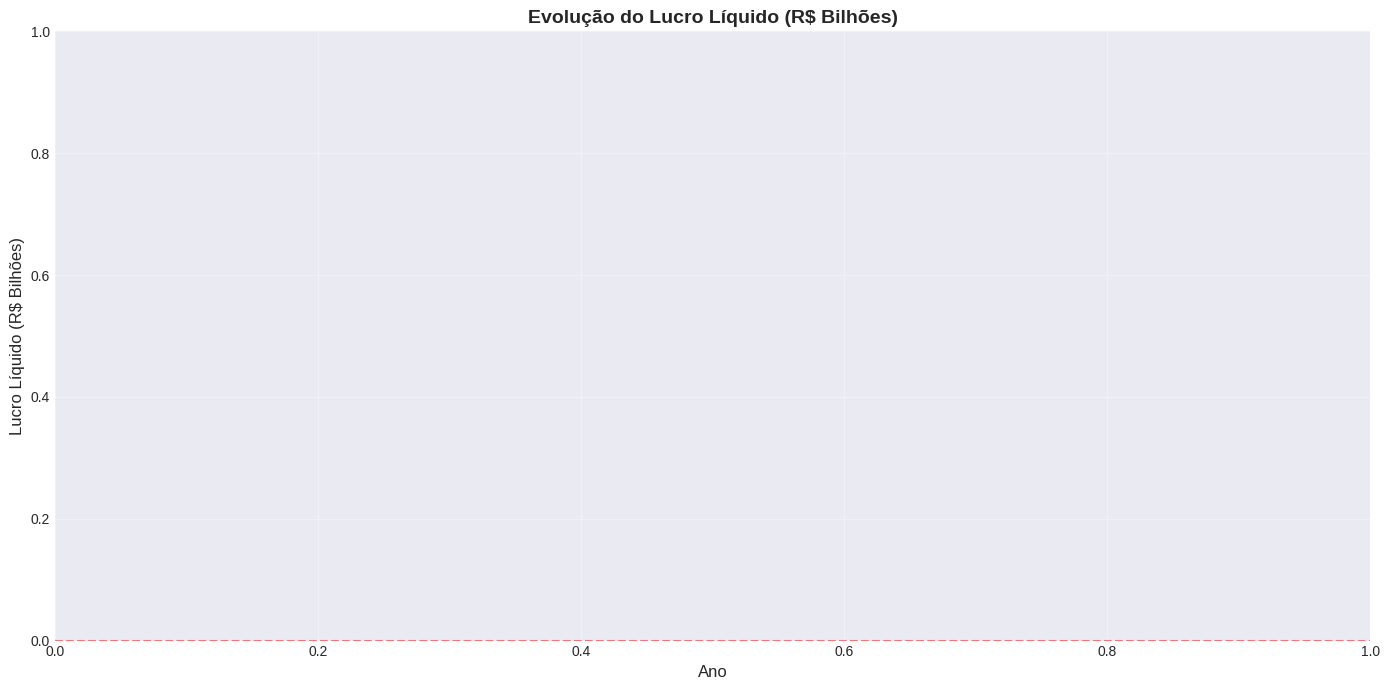

In [3]:
# -*- coding: utf-8 -*-
"""
ANÁLISE FINANCEIRA AVANÇADA COM DADOS CVM
Período: 2010-2024 | Dados Fundamentalistas Históricos
Baseado no modelo yfinance adaptado para CVM (Comissão de Valores Mobiliários)
"""

import os
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, kurtosis, skew

# Para download de arquivos
import requests
from zipfile import ZipFile
from io import BytesIO

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

"""
# 1. DESCRIÇÃO DOS DATASETS
"""

print("="*100)
print("DESCRIÇÃO DOS DATASETS - FONTE: CVM (Comissão de Valores Mobiliários)")
print("="*100)

datasets_descricao = {
    "Dataset 1 - DRE (Demonstração de Resultados)": {
        "Origem": "CVM - Dados Abertos (formato ZIP consolidado)",
        "Formato": "Estruturado (CSV dentro de ZIP)",
        "Estrutura": "Contas contábeis por empresa/período",
        "Volume Estimado": "~500 empresas × 15 anos × 4 trimestres ≈ 30,000 registros",
        "Frequência": "Anual (DFP)",
        "Veracidade": "Alta - dados oficiais auditados",
        "Colunas Principais": ['Receita Líquida', 'Lucro Líquido', 'EBITDA', 'Custos']
    },
    "Dataset 2 - Balanço Patrimonial (BPA/BPP)": {
        "Origem": "CVM - Dados Abertos (formato ZIP consolidado)",
        "Formato": "Estruturado (CSV dentro de ZIP)",
        "Estrutura": "Ativos, Passivos e Patrimônio Líquido",
        "Volume Estimado": "~500 empresas × 15 anos ≈ 7,500 registros",
        "Frequência": "Anual (DFP)",
        "Veracidade": "Alta - dados oficiais auditados",
        "Colunas Principais": ['Ativo Total', 'Passivo Total', 'Patrimônio Líquido']
    }
}

for dataset, info in datasets_descricao.items():
    print(f"\n{dataset}:")
    for key, value in info.items():
        print(f"  • {key}: {value}")

"""
# 2. CONFIGURAÇÃO DO PROJETO
"""

print(f"\n{'='*80}")
print("CONFIGURAÇÃO DA ANÁLISE")
print(f"{'='*80}")

# Período de análise
ANO_INICIO = 2010
ANO_FIM = 2025
ANOS = list(range(ANO_INICIO, ANO_FIM + 1))

# Empresas de interesse (buscar por nome parcial)
EMPRESAS_INTERESSE = {
    'PETROBRAS': ['PETROBRAS', 'PETROLEO BRASILEIRO'],
    'VALE': ['VALE S.A.', 'VALE SA'],
    'ITAU': ['ITAU UNIBANCO', 'ITAÚ UNIBANCO'],
    'BRADESCO': ['BRADESCO', 'BCO BRADESCO'],
    'AMBEV': ['AMBEV'],
    'B3': ['B3 S.A.', 'B3 SA'],
    'WEG': ['WEG S.A.', 'WEG SA'],
    'MAGAZINE LUIZA': ['MAGAZINE LUIZA', 'MAGAZ LUIZA'],
    'NATURA': ['NATURA']
}

print(f"• Período: {ANO_INICIO} a {ANO_FIM}")
print(f"• Anos para análise: {len(ANOS)} anos")
print(f"• Empresas de interesse: {len(EMPRESAS_INTERESSE)}")

"""
# 3. FUNÇÕES DE EXTRAÇÃO E PROCESSAMENTO
"""

def baixar_dados_cvm_zip(ano):
    """
    Baixa dados da CVM em formato ZIP para um ano específico
    Novo formato: arquivo ZIP consolidado
    """
    base_url = "https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS"

    try:
        url_zip = f"{base_url}/dfp_cia_aberta_{ano}.zip"
        print(f"    Baixando arquivo ZIP {ano}...", end=" ")

        response = requests.get(url_zip, timeout=30)
        response.raise_for_status()

        # Abrir ZIP em memória
        zip_file = ZipFile(BytesIO(response.content))

        # Extrair arquivos relevantes
        dados = {}

        # Procurar DRE
        dre_files = [f for f in zip_file.namelist() if 'DRE' in f and f.endswith('.csv')]
        if dre_files:
            dre = pd.read_csv(zip_file.open(dre_files[0]), sep=';', decimal=',',
                            encoding='ISO-8859-1', low_memory=False)
            dados['DRE'] = dre
            print(f"DRE: {len(dre)} registros", end=" | ")

        # Procurar BPA (Balanço Patrimonial Ativo)
        bpa_files = [f for f in zip_file.namelist() if 'BPA' in f and f.endswith('.csv')]
        if bpa_files:
            bpa = pd.read_csv(zip_file.open(bpa_files[0]), sep=';', decimal=',',
                            encoding='ISO-8859-1', low_memory=False)
            dados['BPA'] = bpa
            print(f"BPA: {len(bpa)} registros", end=" | ")

        # Procurar BPP (Balanço Patrimonial Passivo)
        bpp_files = [f for f in zip_file.namelist() if 'BPP' in f and f.endswith('.csv')]
        if bpp_files:
            bpp = pd.read_csv(zip_file.open(bpp_files[0]), sep=';', decimal=',',
                            encoding='ISO-8859-1', low_memory=False)
            dados['BPP'] = bpp
            print(f"BPP: {len(bpp)} registros")

        if dados:
            print(f"  ✓ Dados de {ano} carregados com sucesso")
            return dados
        else:
            print(f"  ✗ Nenhum arquivo encontrado no ZIP")
            return None

    except Exception as e:
        print(f"✗ Erro: {str(e)[:80]}")
        return None

def encontrar_empresa(df, nomes_busca):
    """
    Encontra empresa no DataFrame usando lista de variações de nome
    """
    for nome in nomes_busca:
        df_filtrado = df[df['DENOM_CIA'].str.contains(nome, case=False, na=False)]
        if len(df_filtrado) > 0:
            return df_filtrado
    return pd.DataFrame()

def extrair_conta(df, cd_conta):
    """
    Extrai valor de uma conta específica do DataFrame
    """
    df_filtrado = df[df['CD_CONTA'] == cd_conta]

    if len(df_filtrado) > 0:
        return df_filtrado['VL_CONTA'].iloc[0]
    return np.nan

def processar_dados_empresa(dados_anos, nome_empresa, nomes_busca):
    """
    Processa dados de múltiplos anos para uma empresa específica
    """
    resultados = []

    for ano, dados in dados_anos.items():
        if dados is None or 'DRE' not in dados:
            continue

        dre = dados['DRE']
        bpa = dados.get('BPA', pd.DataFrame())
        bpp = dados.get('BPP', pd.DataFrame())

        # Filtrar por empresa
        dre_empresa = encontrar_empresa(dre, nomes_busca)

        if len(dre_empresa) == 0:
            continue

        # Extrair indicadores principais
        registro = {
            'Ano': ano,
            'Empresa': nome_empresa,
            'CNPJ': dre_empresa['CNPJ_CIA'].iloc[0] if len(dre_empresa) > 0 else None,
        }

        # DRE - Contas principais
        for codigo, nome in [
            ('3.01', 'Receita_Liquida'),
            ('3.05', 'Resultado_Bruto'),
            ('3.11', 'Resultado_Antes_IR'),
            ('3.', 'Lucro_Liquido')
        ]:
            valor = extrair_conta(dre_empresa, codigo)
            # Converter para numérico
            registro[nome] = pd.to_numeric(valor, errors='coerce')

        # BPA - Ativo Total
        if len(bpa) > 0:
            bpa_empresa = encontrar_empresa(bpa, nomes_busca)
            if len(bpa_empresa) > 0:
                ativo_total = extrair_conta(bpa_empresa, '1')
                registro['Ativo_Total'] = pd.to_numeric(ativo_total, errors='coerce')

        # BPP - Patrimônio Líquido e Passivo
        if len(bpp) > 0:
            bpp_empresa = encontrar_empresa(bpp, nomes_busca)
            if len(bpp_empresa) > 0:
                patrimonio_liq = extrair_conta(bpp_empresa, '2.03')
                registro['Patrimonio_Liquido'] = pd.to_numeric(patrimonio_liq, errors='coerce')

                passivo_total = extrair_conta(bpp_empresa, '2')
                registro['Passivo_Total'] = pd.to_numeric(passivo_total, errors='coerce')

        resultados.append(registro)

    return pd.DataFrame(resultados)

"""
# 4. EXTRAÇÃO DE DADOS
"""

print(f"\n{'='*80}")
print("ETAPA 1: EXTRAÇÃO DE DADOS DA CVM")
print(f"{'='*80}")

# Baixar dados de todos os anos
dados_por_ano = {}

for ano in ANOS:
    print(f"\n📊 Ano {ano}:")
    dados = baixar_dados_cvm_zip(ano)
    if dados:
        dados_por_ano[ano] = dados

print(f"\n✓ Total de anos processados: {len(dados_por_ano)}/{len(ANOS)}")

"""
# 5. PROCESSAMENTO E CONSOLIDAÇÃO
"""

print(f"\n{'='*80}")
print("ETAPA 2: PROCESSAMENTO E CONSOLIDAÇÃO DOS DADOS")
print(f"{'='*80}")

# Processar dados para cada empresa
dados_empresas = {}

for nome_curto, nomes_busca in EMPRESAS_INTERESSE.items():
    print(f"\n📈 Processando {nome_curto}...")
    df_empresa = processar_dados_empresa(dados_por_ano, nome_curto, nomes_busca)

    if len(df_empresa) > 0:
        dados_empresas[nome_curto] = df_empresa
        print(f"  ✓ {len(df_empresa)} registros encontrados")
    else:
        print(f"  ✗ Nenhum dado encontrado")

# Consolidar todos os dados
if len(dados_empresas) > 0:
    df_consolidado = pd.concat(dados_empresas.values(), ignore_index=True)
    print(f"\n✓ Dados consolidados: {len(df_consolidado)} registros de {len(dados_empresas)} empresas")
else:
    print(f"\n✗ Nenhum dado foi extraído. Verifique os nomes das empresas ou os anos.")
    df_consolidado = pd.DataFrame()

"""
# 6. CÁLCULO DE INDICADORES FINANCEIROS
"""

if len(df_consolidado) > 0:
    print(f"\n{'='*80}")
    print("ETAPA 3: CÁLCULO DE INDICADORES FINANCEIROS")
    print(f"{'='*80}")

    df_indicadores = df_consolidado.copy()

    # Converter todas as colunas numéricas
    colunas_numericas = ['Receita_Liquida', 'Resultado_Bruto', 'Resultado_Antes_IR',
                         'Lucro_Liquido', 'Ativo_Total', 'Patrimonio_Liquido', 'Passivo_Total']

    for col in colunas_numericas:
        if col in df_indicadores.columns:
            df_indicadores[col] = pd.to_numeric(df_indicadores[col], errors='coerce')

    # Calcular indicadores
    print("\n📊 Calculando indicadores...")

    # Margem Líquida
    df_indicadores['Margem_Liquida'] = (
        df_indicadores['Lucro_Liquido'] / df_indicadores['Receita_Liquida'] * 100
    )
    print("  ✓ Margem Líquida")

    # ROE (Return on Equity)
    df_indicadores['ROE'] = (
        df_indicadores['Lucro_Liquido'] / df_indicadores['Patrimonio_Liquido'] * 100
    )
    print("  ✓ ROE")

    # ROA (Return on Assets)
    df_indicadores['ROA'] = (
        df_indicadores['Lucro_Liquido'] / df_indicadores['Ativo_Total'] * 100
    )
    print("  ✓ ROA")

    # Endividamento
    df_indicadores['Endividamento'] = (
        (df_indicadores['Passivo_Total'] - df_indicadores['Patrimonio_Liquido']) /
        df_indicadores['Patrimonio_Liquido'] * 100
    )
    print("  ✓ Endividamento")

    # Crescimento de Receita (YoY)
    df_indicadores = df_indicadores.sort_values(['Empresa', 'Ano'])
    df_indicadores['Crescimento_Receita'] = df_indicadores.groupby('Empresa')['Receita_Liquida'].pct_change() * 100
    print("  ✓ Crescimento de Receita")

    # Remover infinitos e valores muito altos
    df_indicadores = df_indicadores.replace([np.inf, -np.inf], np.nan)

    print(f"\n✓ Indicadores calculados com sucesso!")

    """
    # 7. ANÁLISE EXPLORATÓRIA DESCRITIVA
    """

    print(f"\n{'='*80}")
    print("ETAPA 4: ANÁLISE EXPLORATÓRIA DESCRITIVA")
    print(f"{'='*80}")

    # Estatísticas gerais
    print("\n📊 ESTATÍSTICAS DESCRITIVAS - INDICADORES FINANCEIROS:")

    colunas_analise = ['Receita_Liquida', 'Lucro_Liquido', 'Margem_Liquida',
                       'ROE', 'ROA', 'Endividamento', 'Crescimento_Receita']

    estatisticas = df_indicadores[colunas_analise].describe()
    print(estatisticas.round(2))

    # Estatísticas por empresa
    print("\n📊 MÉDIAS POR EMPRESA:")
    medias_empresa = df_indicadores.groupby('Empresa')[colunas_analise].mean()
    print(medias_empresa.round(2))

    """
    # 8. VISUALIZAÇÕES
    """

    print(f"\n{'='*80}")
    print("ETAPA 5: GERAÇÃO DE GRÁFICOS")
    print(f"{'='*80}")

    print("\n📈 Gerando gráficos...")

    # Gráfico 1: Evolução da Receita Líquida
    fig1, ax1 = plt.subplots(figsize=(14, 7))

    for empresa in df_indicadores['Empresa'].unique():
        df_emp = df_indicadores[df_indicadores['Empresa'] == empresa].sort_values('Ano')
        if not df_emp['Receita_Liquida'].isna().all():
            ax1.plot(df_emp['Ano'], df_emp['Receita_Liquida'] / 1e9,
                     marker='o', linewidth=2, label=empresa)

    ax1.set_title('Evolução da Receita Líquida (R$ Bilhões)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Ano', fontsize=12)
    ax1.set_ylabel('Receita Líquida (R$ Bilhões)', fontsize=12)
    ax1.legend(fontsize=9, loc='best')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('cvm_receita_evolucao.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico 1: cvm_receita_evolucao.png")

    # Gráfico 2: Evolução da Margem Líquida
    fig2, ax2 = plt.subplots(figsize=(14, 7))

    for empresa in df_indicadores['Empresa'].unique():
        df_emp = df_indicadores[df_indicadores['Empresa'] == empresa].sort_values('Ano')
        if not df_emp['Margem_Liquida'].isna().all():
            ax2.plot(df_emp['Ano'], df_emp['Margem_Liquida'],
                    marker='o', linewidth=2, label=empresa)

    ax2.set_title('Evolução da Margem Líquida (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Ano', fontsize=12)
    ax2.set_ylabel('Margem Líquida (%)', fontsize=12)
    ax2.legend(fontsize=9, loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('cvm_margem_liquida.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico 2: cvm_margem_liquida.png")

    # Gráfico 3: ROE por Empresa
    fig3, ax3 = plt.subplots(figsize=(14, 7))

    for empresa in df_indicadores['Empresa'].unique():
        df_emp = df_indicadores[df_indicadores['Empresa'] == empresa].sort_values('Ano')
        if not df_emp['ROE'].isna().all():
            ax3.plot(df_emp['Ano'], df_emp['ROE'],
                    marker='s', linewidth=2, label=empresa)

    ax3.set_title('Evolução do ROE - Return on Equity (%)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Ano', fontsize=12)
    ax3.set_ylabel('ROE (%)', fontsize=12)
    ax3.legend(fontsize=9, loc='best')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('cvm_roe_evolucao.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico 3: cvm_roe_evolucao.png")

    # Gráfico 4: Lucro Líquido
    fig4, ax4 = plt.subplots(figsize=(14, 7))

    for empresa in df_indicadores['Empresa'].unique():
        df_emp = df_indicadores[df_indicadores['Empresa'] == empresa].sort_values('Ano')
        if not df_emp['Lucro_Liquido'].isna().all():
            ax4.plot(df_emp['Ano'], df_emp['Lucro_Liquido'] / 1e9,
                     marker='o', linewidth=2, label=empresa)

    ax4.set_title('Evolução do Lucro Líquido (R$ Bilhões)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Ano', fontsize=12)
    ax4.set_ylabel('Lucro Líquido (R$ Bilhões)', fontsize=12)
    ax4.legend(fontsize=9, loc='best')
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('cvm_lucro_evolucao.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico 4: cvm_lucro_evolucao.png")

    """
    # 9. EXPORTAÇÃO DE RESULTADOS
    """

    print(f"\n{'='*80}")
    print("ETAPA 6: EXPORTAÇÃO DOS RESULTADOS")
    print(f"{'='*80}")

    try:
        # Exportar dados consolidados
        df_consolidado.to_csv('cvm_dados_consolidados.csv', index=False)
        print("✓ Salvo: cvm_dados_consolidados.csv")

        # Exportar indicadores calculados
        df_indicadores.to_csv('cvm_indicadores_financeiros.csv', index=False)
        print("✓ Salvo: cvm_indicadores_financeiros.csv")

        # Exportar estatísticas
        estatisticas.to_csv('cvm_estatisticas_descritivas.csv')
        print("✓ Salvo: cvm_estatisticas_descritivas.csv")

        # Exportar médias por empresa
        medias_empresa.to_csv('cvm_medias_por_empresa.csv')
        print("✓ Salvo: cvm_medias_por_empresa.csv")

    except Exception as e:
        print(f"✗ Erro ao exportar: {e}")

    print(f"\n{'='*100}")
    print("ANÁLISE CONCLUÍDA COM SUCESSO!")
    print(f"{'='*100}")
    print(f"📊 Empresas analisadas: {len(dados_empresas)}")
    print(f"📅 Período: {ANO_INICIO}-{ANO_FIM}")
    print(f"📈 Total de registros: {len(df_indicadores)}")
    print(f"📁 Gráficos gerados: 4")
    print(f"💾 Arquivos CSV exportados: 4")
    print(f"\n✅ Todos os arquivos foram salvos no diretório atual!")

else:
    print("\n⚠️ Nenhum dado foi extraído. Não é possível gerar gráficos ou estatísticas.")
    print("Verifique:")
    print("  • Os nomes das empresas no dicionário EMPRESAS_INTERESSE")
    print("  • Os anos definidos (ANO_INICIO e ANO_FIM)")
    print("  • Sua conexão com a internet")

DESCRIÇÃO DOS DATASETS - FONTE: CVM (Comissão de Valores Mobiliários)

Dataset 1 - DRE (Demonstração de Resultados):
  • Origem: CVM - Dados Abertos (formato ZIP consolidado)
  • Formato: Estruturado (CSV dentro de ZIP)
  • Estrutura: Contas contábeis por empresa/período
  • Volume Estimado: ~500 empresas × 15 anos × 4 trimestres ≈ 30,000 registros
  • Frequência: Anual (DFP)
  • Veracidade: Alta - dados oficiais auditados
  • Colunas Principais: ['Receita Líquida', 'Lucro Líquido', 'EBITDA', 'Custos']

Dataset 2 - Balanço Patrimonial (BPA/BPP):
  • Origem: CVM - Dados Abertos (formato ZIP consolidado)
  • Formato: Estruturado (CSV dentro de ZIP)
  • Estrutura: Ativos, Passivos e Patrimônio Líquido
  • Volume Estimado: ~500 empresas × 15 anos ≈ 7,500 registros
  • Frequência: Anual (DFP)
  • Veracidade: Alta - dados oficiais auditados
  • Colunas Principais: ['Ativo Total', 'Passivo Total', 'Patrimônio Líquido']

CONFIGURAÇÃO DA ANÁLISE
• Período: 2010 a 2025
• Anos para análise: 16 an

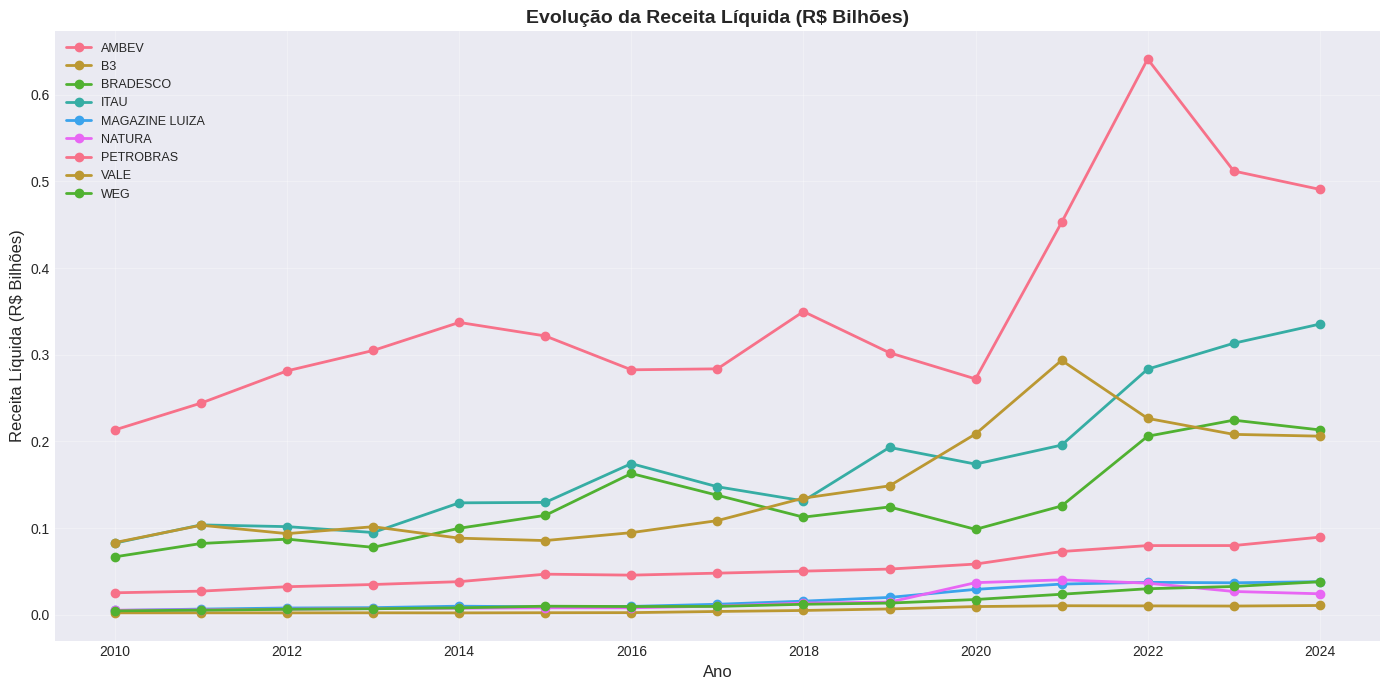

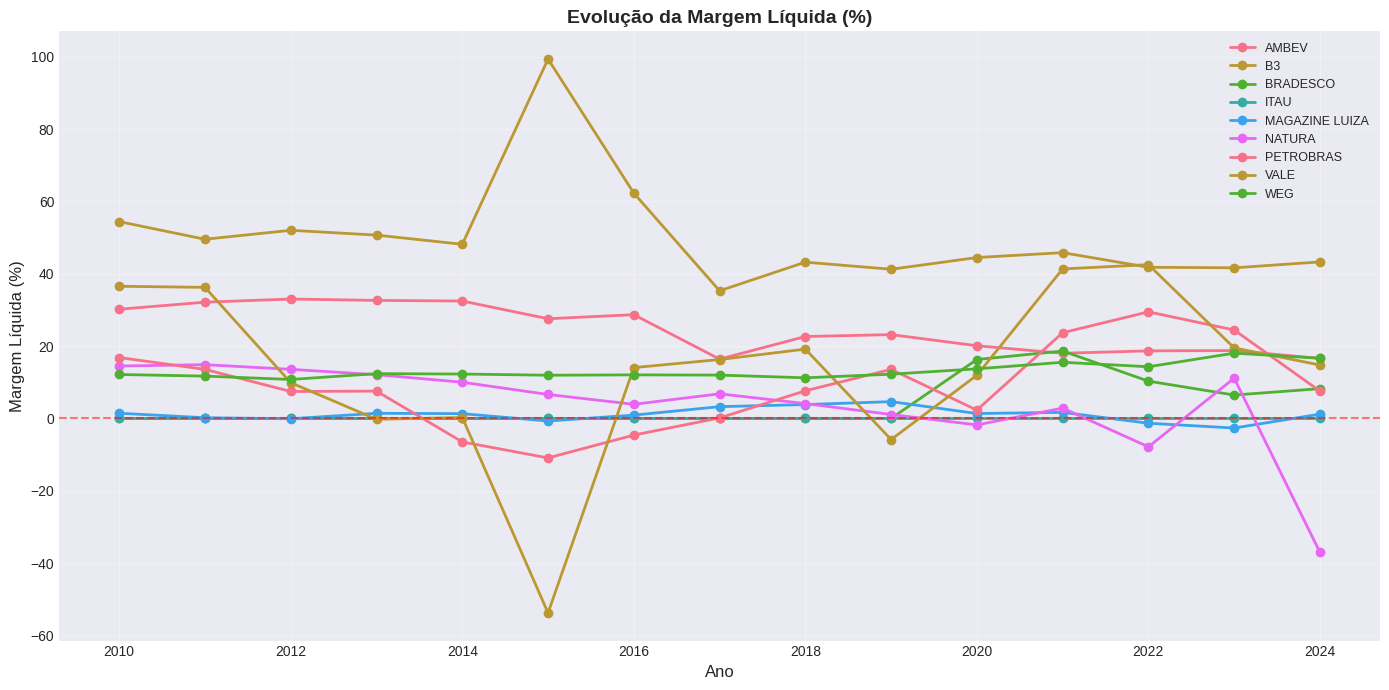

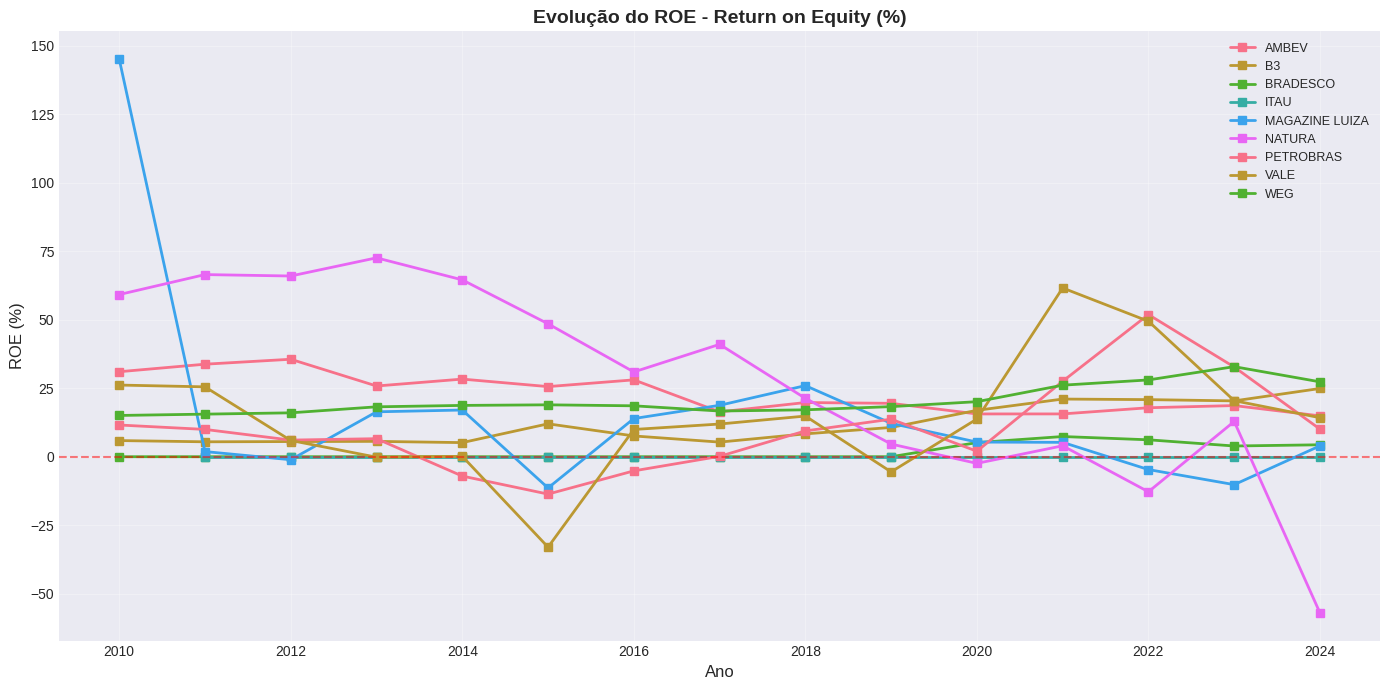

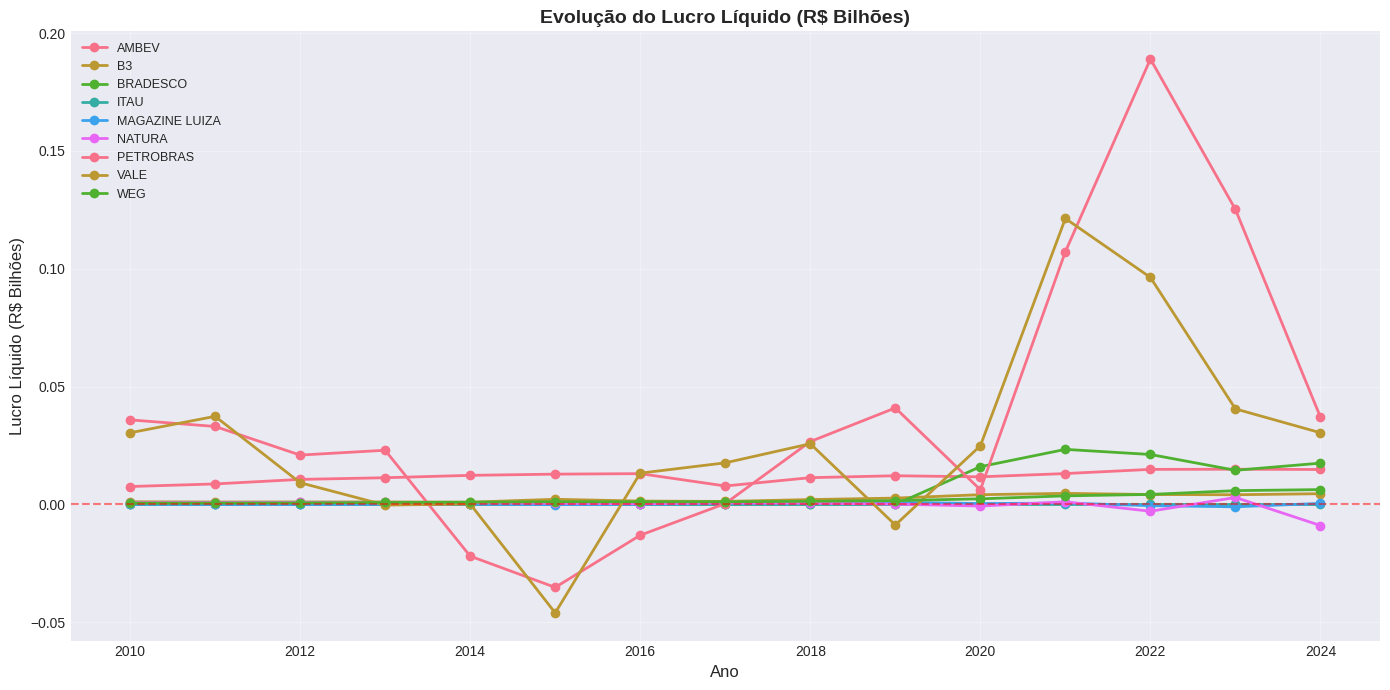

In [4]:
# -*- coding: utf-8 -*-
"""
ANÁLISE FINANCEIRA AVANÇADA COM DADOS CVM - VERSÃO CORRIGIDA
Período: 2010-2024 | Dados Fundamentalistas Históricos
Baseado no modelo yfinance adaptado para CVM (Comissão de Valores Mobiliários)
"""

import os
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Para download de arquivos
import requests
from zipfile import ZipFile
from io import BytesIO

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

"""
# 1. DESCRIÇÃO DOS DATASETS
"""

print("="*100)
print("DESCRIÇÃO DOS DATASETS - FONTE: CVM (Comissão de Valores Mobiliários)")
print("="*100)

datasets_descricao = {
    "Dataset 1 - DRE (Demonstração de Resultados)": {
        "Origem": "CVM - Dados Abertos (formato ZIP consolidado)",
        "Formato": "Estruturado (CSV dentro de ZIP)",
        "Estrutura": "Contas contábeis por empresa/período",
        "Volume Estimado": "~500 empresas × 15 anos × 4 trimestres ≈ 30,000 registros",
        "Frequência": "Anual (DFP)",
        "Veracidade": "Alta - dados oficiais auditados",
        "Colunas Principais": ['Receita Líquida', 'Lucro Líquido', 'EBITDA', 'Custos']
    },
    "Dataset 2 - Balanço Patrimonial (BPA/BPP)": {
        "Origem": "CVM - Dados Abertos (formato ZIP consolidado)",
        "Formato": "Estruturado (CSV dentro de ZIP)",
        "Estrutura": "Ativos, Passivos e Patrimônio Líquido",
        "Volume Estimado": "~500 empresas × 15 anos ≈ 7,500 registros",
        "Frequência": "Anual (DFP)",
        "Veracidade": "Alta - dados oficiais auditados",
        "Colunas Principais": ['Ativo Total', 'Passivo Total', 'Patrimônio Líquido']
    }
}

for dataset, info in datasets_descricao.items():
    print(f"\n{dataset}:")
    for key, value in info.items():
        print(f"  • {key}: {value}")

"""
# 2. CONFIGURAÇÃO DO PROJETO
"""

print(f"\n{'='*80}")
print("CONFIGURAÇÃO DA ANÁLISE")
print(f"{'='*80}")

# Período de análise
ANO_INICIO = 2010
ANO_FIM = 2025
ANOS = list(range(ANO_INICIO, ANO_FIM + 1))

# Empresas de interesse (buscar por nome parcial)
EMPRESAS_INTERESSE = {
    'PETROBRAS': ['PETROBRAS', 'PETROLEO BRASILEIRO'],
    'VALE': ['VALE S.A.', 'VALE SA'],
    'ITAU': ['ITAU UNIBANCO', 'ITAÚ UNIBANCO'],
    'BRADESCO': ['BRADESCO', 'BCO BRADESCO'],
    'AMBEV': ['AMBEV'],
    'B3': ['B3 S.A.', 'B3 SA'],
    'WEG': ['WEG S.A.', 'WEG SA'],
    'MAGAZINE LUIZA': ['MAGAZINE LUIZA', 'MAGAZ LUIZA'],
    'NATURA': ['NATURA']
}

print(f"• Período: {ANO_INICIO} a {ANO_FIM}")
print(f"• Anos para análise: {len(ANOS)} anos")
print(f"• Empresas de interesse: {len(EMPRESAS_INTERESSE)}")

"""
# 3. FUNÇÕES DE EXTRAÇÃO E PROCESSAMENTO
"""

def encontrar_empresa(df, nomes_busca):
    """
    Encontra empresa no DataFrame usando lista de variações de nome
    """
    for nome in nomes_busca:
        df_filtrado = df[df['DENOM_CIA'].str.contains(nome, case=False, na=False)]
        if len(df_filtrado) > 0:
            return df_filtrado
    return pd.DataFrame()

# --- FUNÇÃO REFATORADA 1 ---
def baixar_dados_cvm_zip(ano):
    """
    Baixa dados da CVM e PRIORIZA arquivos CONSOLIDADOS (CON)
    """
    base_url = "https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS"

    try:
        url_zip = f"{base_url}/dfp_cia_aberta_{ano}.zip"
        print(f"    Baixando arquivo ZIP {ano}...", end=" ")

        response = requests.get(url_zip, timeout=60) # Timeout aumentado
        response.raise_for_status()

        zip_file = ZipFile(BytesIO(response.content))
        dados = {}

        # Função auxiliar para pegar o arquivo correto (Prioriza CONSOLIDADO)
        def pegar_arquivo_certo(termos_busca):
            arquivos = [f for f in zip_file.namelist() if all(t in f for t in termos_busca) and f.endswith('.csv')]
            # Prioriza arquivo que tem "CON" (Consolidado) no nome
            arquivos_con = [f for f in arquivos if '_CON_' in f]
            return arquivos_con[0] if arquivos_con else (arquivos[0] if arquivos else None)

        # Carregar DRE (Demonstração de Resultado)
        arquivo_dre = pegar_arquivo_certo(['DRE'])
        if arquivo_dre:
            dados['DRE'] = pd.read_csv(zip_file.open(arquivo_dre), sep=';', decimal=',', encoding='ISO-8859-1', low_memory=False)
            print(f"DRE: {len(dados['DRE'])} regs", end=" | ")

        # Carregar BPP (Passivo + Patrimônio)
        arquivo_bpp = pegar_arquivo_certo(['BPP'])
        if arquivo_bpp:
            dados['BPP'] = pd.read_csv(zip_file.open(arquivo_bpp), sep=';', decimal=',', encoding='ISO-8859-1', low_memory=False)
            print(f"BPP: {len(dados['BPP'])} regs", end=" | ")

        # Carregar BPA (Ativo)
        arquivo_bpa = pegar_arquivo_certo(['BPA'])
        if arquivo_bpa:
             dados['BPA'] = pd.read_csv(zip_file.open(arquivo_bpa), sep=';', decimal=',', encoding='ISO-8859-1', low_memory=False)
             print(f"BPA: {len(dados['BPA'])} regs")

        if dados:
            print(f"    ✓ Sucesso")
            return dados
        return None

    except Exception as e:
        print(f"✗ Erro: {str(e)[:80]}")
        return None

# --- FUNÇÃO REFATORADA 2 ---
def processar_dados_empresa(dados_anos, nome_empresa, nomes_busca):
    """
    Processa dados usando os códigos contábeis CORRETOS (3.11 e 3.15) e busca Ativo Total no BPA
    """
    resultados = []

    for ano, dados in dados_anos.items():
        if 'DRE' not in dados: continue

        dre = dados['DRE']
        bpp = dados.get('BPP', pd.DataFrame())
        bpa = dados.get('BPA', pd.DataFrame())

        # Filtra a empresa
        dre_emp = encontrar_empresa(dre, nomes_busca)

        # Filtra apenas o 'ÚLTIMO' exercício para evitar duplicatas
        if 'ORDEM_EXERC' in dre_emp.columns:
            dre_emp = dre_emp[dre_emp['ORDEM_EXERC'] == 'ÚLTIMO']

        if len(dre_emp) == 0: continue

        registro = {
            'Ano': ano,
            'Empresa': nome_empresa,
            'CNPJ': dre_emp['CNPJ_CIA'].iloc[0] if 'CNPJ_CIA' in dre_emp.columns else None
        }

        # Função auxiliar interna para pegar valor com segurança
        def pegar_valor(df_f, codigos):
            for cod in codigos:
                val = df_f[df_f['CD_CONTA'] == cod]['VL_CONTA']
                if len(val) > 0: return pd.to_numeric(val.iloc[0], errors='coerce')
            return 0.0

        # --- DRE ---
        registro['Receita_Liquida'] = pegar_valor(dre_emp, ['3.01'])
        registro['Resultado_Bruto'] = pegar_valor(dre_emp, ['3.03', '3.05'])
        # Tenta Lucro Consolidado (3.15) primeiro, se não achar, tenta o Antes do IR (3.11)
        registro['Lucro_Liquido'] = pegar_valor(dre_emp, ['3.15', '3.13', '3.11'])
        registro['Resultado_Antes_IR'] = pegar_valor(dre_emp, ['3.11'])

        # --- BPP (Passivo + Patrimônio) ---
        if len(bpp) > 0:
            bpp_emp = encontrar_empresa(bpp, nomes_busca)
            if 'ORDEM_EXERC' in bpp_emp.columns:
                bpp_emp = bpp_emp[bpp_emp['ORDEM_EXERC'] == 'ÚLTIMO']

            registro['Patrimonio_Liquido'] = pegar_valor(bpp_emp, ['2.03', '2.07'])
            registro['Passivo_Total'] = pegar_valor(bpp_emp, ['2'])

        # --- BPA (Ativo) ---
        if len(bpa) > 0:
            bpa_emp = encontrar_empresa(bpa, nomes_busca)
            if 'ORDEM_EXERC' in bpa_emp.columns:
                bpa_emp = bpa_emp[bpa_emp['ORDEM_EXERC'] == 'ÚLTIMO']

            # Código '1' é o Ativo Total
            registro['Ativo_Total'] = pegar_valor(bpa_emp, ['1'])

        resultados.append(registro)

    return pd.DataFrame(resultados)

"""
# 4. EXTRAÇÃO DE DADOS
"""

print(f"\n{'='*80}")
print("ETAPA 1: EXTRAÇÃO DE DADOS DA CVM")
print(f"{'='*80}")

# Baixar dados de todos os anos
dados_por_ano = {}

for ano in ANOS:
    print(f"\n📊 Ano {ano}:")
    dados = baixar_dados_cvm_zip(ano)
    if dados:
        dados_por_ano[ano] = dados

print(f"\n✓ Total de anos processados: {len(dados_por_ano)}/{len(ANOS)}")

"""
# 5. PROCESSAMENTO E CONSOLIDAÇÃO
"""

print(f"\n{'='*80}")
print("ETAPA 2: PROCESSAMENTO E CONSOLIDAÇÃO DOS DADOS")
print(f"{'='*80}")

# Processar dados para cada empresa
dados_empresas = {}

for nome_curto, nomes_busca in EMPRESAS_INTERESSE.items():
    print(f"\n📈 Processando {nome_curto}...")
    df_empresa = processar_dados_empresa(dados_por_ano, nome_curto, nomes_busca)

    if len(df_empresa) > 0:
        dados_empresas[nome_curto] = df_empresa
        print(f"  ✓ {len(df_empresa)} registros encontrados")
    else:
        print(f"  ✗ Nenhum dado encontrado")

# Consolidar todos os dados
if len(dados_empresas) > 0:
    df_consolidado = pd.concat(dados_empresas.values(), ignore_index=True)
    print(f"\n✓ Dados consolidados: {len(df_consolidado)} registros de {len(dados_empresas)} empresas")
else:
    print(f"\n✗ Nenhum dado foi extraído. Verifique os nomes das empresas ou os anos.")
    df_consolidado = pd.DataFrame()

"""
# 6. CÁLCULO DE INDICADORES FINANCEIROS
"""

if len(df_consolidado) > 0:
    print(f"\n{'='*80}")
    print("ETAPA 3: CÁLCULO DE INDICADORES FINANCEIROS")
    print(f"{'='*80}")

    df_indicadores = df_consolidado.copy()

    # Garantir que colunas existem (mesmo que vazias) para não quebrar o código
    cols_necessarias = ['Receita_Liquida', 'Lucro_Liquido', 'Ativo_Total', 'Patrimonio_Liquido', 'Passivo_Total']
    for col in cols_necessarias:
        if col not in df_indicadores.columns:
            df_indicadores[col] = np.nan

    # Converter todas as colunas numéricas
    colunas_numericas = ['Receita_Liquida', 'Resultado_Bruto', 'Resultado_Antes_IR',
                         'Lucro_Liquido', 'Ativo_Total', 'Patrimonio_Liquido', 'Passivo_Total']

    for col in colunas_numericas:
        if col in df_indicadores.columns:
            df_indicadores[col] = pd.to_numeric(df_indicadores[col], errors='coerce')

    # Calcular indicadores
    print("\n📊 Calculando indicadores...")

    # Margem Líquida
    df_indicadores['Margem_Liquida'] = (
        df_indicadores['Lucro_Liquido'] / df_indicadores['Receita_Liquida'] * 100
    )
    print("  ✓ Margem Líquida")

    # ROE (Return on Equity)
    df_indicadores['ROE'] = (
        df_indicadores['Lucro_Liquido'] / df_indicadores['Patrimonio_Liquido'] * 100
    )
    print("  ✓ ROE")

    # ROA (Return on Assets)
    df_indicadores['ROA'] = (
        df_indicadores['Lucro_Liquido'] / df_indicadores['Ativo_Total'] * 100
    )
    print("  ✓ ROA")

    # Endividamento
    df_indicadores['Endividamento'] = (
        (df_indicadores['Passivo_Total'] - df_indicadores['Patrimonio_Liquido']) /
        df_indicadores['Patrimonio_Liquido'] * 100
    )
    print("  ✓ Endividamento")

    # Crescimento de Receita (YoY)
    df_indicadores = df_indicadores.sort_values(['Empresa', 'Ano'])
    df_indicadores['Crescimento_Receita'] = df_indicadores.groupby('Empresa')['Receita_Liquida'].pct_change() * 100
    print("  ✓ Crescimento de Receita")

    # Remover infinitos e valores muito altos
    df_indicadores = df_indicadores.replace([np.inf, -np.inf], np.nan)

    print(f"\n✓ Indicadores calculados com sucesso!")

    """
    # 7. ANÁLISE EXPLORATÓRIA DESCRITIVA
    """

    print(f"\n{'='*80}")
    print("ETAPA 4: ANÁLISE EXPLORATÓRIA DESCRITIVA")
    print(f"{'='*80}")

    # Estatísticas gerais
    print("\n📊 ESTATÍSTICAS DESCRITIVAS - INDICADORES FINANCEIROS:")

    colunas_analise = ['Receita_Liquida', 'Lucro_Liquido', 'Margem_Liquida',
                       'ROE', 'ROA', 'Endividamento', 'Crescimento_Receita']

    estatisticas = df_indicadores[colunas_analise].describe()
    print(estatisticas.round(2))

    # Estatísticas por empresa
    print("\n📊 MÉDIAS POR EMPRESA:")
    medias_empresa = df_indicadores.groupby('Empresa')[colunas_analise].mean()
    print(medias_empresa.round(2))

    """
    # 8. VISUALIZAÇÕES
    """

    print(f"\n{'='*80}")
    print("ETAPA 5: GERAÇÃO DE GRÁFICOS")
    print(f"{'='*80}")

    print("\n📈 Gerando gráficos...")

    # Gráfico 1: Evolução da Receita Líquida
    fig1, ax1 = plt.subplots(figsize=(14, 7))

    for empresa in df_indicadores['Empresa'].unique():
        df_emp = df_indicadores[df_indicadores['Empresa'] == empresa].sort_values('Ano')
        if not df_emp['Receita_Liquida'].isna().all():
            ax1.plot(df_emp['Ano'], df_emp['Receita_Liquida'] / 1e9,
                     marker='o', linewidth=2, label=empresa)

    ax1.set_title('Evolução da Receita Líquida (R$ Bilhões)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Ano', fontsize=12)
    ax1.set_ylabel('Receita Líquida (R$ Bilhões)', fontsize=12)
    ax1.legend(fontsize=9, loc='best')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('cvm_receita_evolucao.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico 1: cvm_receita_evolucao.png")

    # Gráfico 2: Evolução da Margem Líquida
    fig2, ax2 = plt.subplots(figsize=(14, 7))

    for empresa in df_indicadores['Empresa'].unique():
        df_emp = df_indicadores[df_indicadores['Empresa'] == empresa].sort_values('Ano')
        if not df_emp['Margem_Liquida'].isna().all():
            ax2.plot(df_emp['Ano'], df_emp['Margem_Liquida'],
                    marker='o', linewidth=2, label=empresa)

    ax2.set_title('Evolução da Margem Líquida (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Ano', fontsize=12)
    ax2.set_ylabel('Margem Líquida (%)', fontsize=12)
    ax2.legend(fontsize=9, loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('cvm_margem_liquida.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico 2: cvm_margem_liquida.png")

    # Gráfico 3: ROE por Empresa
    fig3, ax3 = plt.subplots(figsize=(14, 7))

    for empresa in df_indicadores['Empresa'].unique():
        df_emp = df_indicadores[df_indicadores['Empresa'] == empresa].sort_values('Ano')
        if not df_emp['ROE'].isna().all():
            ax3.plot(df_emp['Ano'], df_emp['ROE'],
                    marker='s', linewidth=2, label=empresa)

    ax3.set_title('Evolução do ROE - Return on Equity (%)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Ano', fontsize=12)
    ax3.set_ylabel('ROE (%)', fontsize=12)
    ax3.legend(fontsize=9, loc='best')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('cvm_roe_evolucao.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico 3: cvm_roe_evolucao.png")

    # Gráfico 4: Lucro Líquido
    fig4, ax4 = plt.subplots(figsize=(14, 7))

    for empresa in df_indicadores['Empresa'].unique():
        df_emp = df_indicadores[df_indicadores['Empresa'] == empresa].sort_values('Ano')
        if not df_emp['Lucro_Liquido'].isna().all():
            ax4.plot(df_emp['Ano'], df_emp['Lucro_Liquido'] / 1e9,
                     marker='o', linewidth=2, label=empresa)

    ax4.set_title('Evolução do Lucro Líquido (R$ Bilhões)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Ano', fontsize=12)
    ax4.set_ylabel('Lucro Líquido (R$ Bilhões)', fontsize=12)
    ax4.legend(fontsize=9, loc='best')
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('cvm_lucro_evolucao.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico 4: cvm_lucro_evolucao.png")

    """
    # 9. EXPORTAÇÃO DE RESULTADOS
    """

    print(f"\n{'='*80}")
    print("ETAPA 6: EXPORTAÇÃO DOS RESULTADOS")
    print(f"{'='*80}")

    try:
        # Exportar dados consolidados
        df_consolidado.to_csv('cvm_dados_consolidados.csv', index=False)
        print("✓ Salvo: cvm_dados_consolidados.csv")

        # Exportar indicadores calculados
        df_indicadores.to_csv('cvm_indicadores_financeiros.csv', index=False)
        print("✓ Salvo: cvm_indicadores_financeiros.csv")

        # Exportar estatísticas
        estatisticas.to_csv('cvm_estatisticas_descritivas.csv')
        print("✓ Salvo: cvm_estatisticas_descritivas.csv")

        # Exportar médias por empresa
        medias_empresa.to_csv('cvm_medias_por_empresa.csv')
        print("✓ Salvo: cvm_medias_por_empresa.csv")

    except Exception as e:
        print(f"✗ Erro ao exportar: {e}")

    print(f"\n{'='*100}")
    print("ANÁLISE CONCLUÍDA COM SUCESSO!")
    print(f"{'='*100}")
    print(f"📊 Empresas analisadas: {len(dados_empresas)}")
    print(f"📅 Período: {ANO_INICIO}-{ANO_FIM}")
    print(f"📈 Total de registros: {len(df_indicadores)}")
    print(f"📁 Gráficos gerados: 4")
    print(f"💾 Arquivos CSV exportados: 4")
    print(f"\n✅ Todos os arquivos foram salvos no diretório atual!")

else:
    print("\n⚠️ Nenhum dado foi extraído. Não é possível gerar gráficos ou estatísticas.")
    print("Verifique:")
    print("  • Os nomes das empresas no dicionário EMPRESAS_INTERESSE")
    print("  • Os anos definidos (ANO_INICIO e ANO_FIM)")
    print("  • Sua conexão com a internet")